In [2]:
import polars as pl
df=pl.read_parquet("../data/processed/train.parquet")
df.head()
df.shape
df.schema

print("Sessions:", df["session"].n_unique())
print("Products:", df["aid"].n_unique())
print(df["type"].value_counts())

Sessions: 100000
Products: 663079
shape: (3, 2)
┌────────┬─────────┐
│ type   ┆ count   │
│ ---    ┆ ---     │
│ str    ┆ u32     │
╞════════╪═════════╡
│ orders ┆ 92902   │
│ carts  ┆ 364579  │
│ clicks ┆ 4770172 │
└────────┴─────────┘


In [4]:
session_lengths = (
    df.group_by("session")
    .agg(pl.len().alias("n_events"))
)
session_lengths.describe()

statistic,session,n_events
str,f64,f64
"""count""",100000.0,100000.0
"""null_count""",0.0,0.0
"""mean""",49999.5,52.27653
"""std""",28867.657797,76.86172
"""min""",0.0,2.0
"""25%""",25000.0,6.0
"""50%""",50000.0,19.0
"""75%""",74999.0,63.0
"""max""",99999.0,495.0


## Session length is strongly right-skewed. The median session contains 19 events, while the mean is 52.3, with sessions reaching up to 495 events.

In [7]:
session_lengths = (
    df.group_by("session")
    .agg(pl.len().alias("n_events"))
)
session_lengths.select("n_events").describe()

statistic,n_events
str,f64
"""count""",100000.0
"""null_count""",0.0
"""mean""",52.27653
"""std""",76.86172
"""min""",2.0
"""25%""",6.0
"""50%""",19.0
"""75%""",63.0
"""max""",495.0


In [6]:
event_distribution = (
    df.group_by("type")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100)
        .alias("percentage")
    )
    .sort("count", descending=True)
)

event_distribution

type,count,percentage
str,u32,f64
"""clicks""",4770172,91.248826
"""carts""",364579,6.974047
"""orders""",92902,1.777126


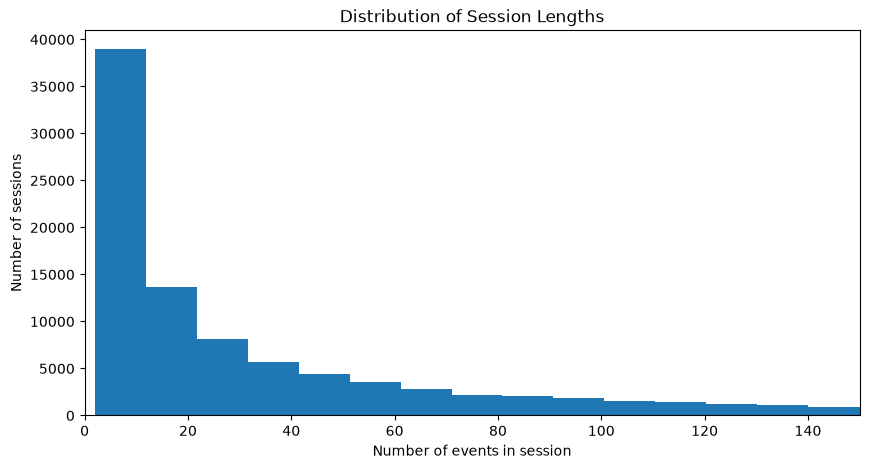

In [8]:
import matplotlib.pyplot as plt

session_lengths_pd = session_lengths.to_pandas()

plt.figure(figsize=(10, 5))
plt.hist(
    session_lengths_pd["n_events"],
    bins=50
)
plt.xlabel("Number of events in session")
plt.ylabel("Number of sessions")
plt.title("Distribution of Session Lengths")
plt.xlim(0, 150)
plt.show()

In [9]:
# unique products per session
unique_items_per_session = (
    df.group_by("session")
    .agg(
        pl.col("aid")
        .n_unique()
        .alias("n_unique_items")
    )
)

unique_items_per_session.select("n_unique_items").describe()

statistic,n_unique_items
str,f64
"""count""",100000.0
"""null_count""",0.0
"""mean""",30.01381
"""std""",42.019834
"""min""",1.0
"""25%""",4.0
"""50%""",12.0
"""75%""",37.0
"""max""",460.0


In [10]:
#gives % of how many items are repeated in a session. 1 means all items are repeated, 0 means all items are unique
session_summary = (
    df.group_by("session")
    .agg(
        pl.len().alias("n_events"),
        pl.col("aid").n_unique().alias("n_unique_items")
    )
    .with_columns(
        (
            1 - pl.col("n_unique_items") / pl.col("n_events")
        ).alias("repeat_ratio")
    )
)

session_summary.select("repeat_ratio").describe()

statistic,repeat_ratio
str,f64
"""count""",100000.0
"""null_count""",0.0
"""mean""",0.318331
"""std""",0.208251
"""min""",0.0
"""25%""",0.166667
"""50%""",0.333333
"""75%""",0.473684
"""max""",0.994318


In [11]:
session_action_flags = (
    df.group_by("session")
    .agg(
        (pl.col("type") == "clicks").any().alias("has_click"),
        (pl.col("type") == "carts").any().alias("has_cart"),
        (pl.col("type") == "orders").any().alias("has_order")
    )
)

session_action_flags.select(
    pl.col("has_click").mean().alias("pct_sessions_with_click"),
    pl.col("has_cart").mean().alias("pct_sessions_with_cart"),
    pl.col("has_order").mean().alias("pct_sessions_with_order"),
)

pct_sessions_with_click,pct_sessions_with_cart,pct_sessions_with_order
f64,f64,f64
1.0,0.463,0.23432


In [12]:
actions_per_session = (
    df.group_by("session")
    .agg(
        (pl.col("type") == "clicks").sum().alias("n_clicks"),
        (pl.col("type") == "carts").sum().alias("n_carts"),
        (pl.col("type") == "orders").sum().alias("n_orders")
    )
)

actions_per_session.select(
    "n_clicks",
    "n_carts",
    "n_orders"
).describe()

statistic,n_clicks,n_carts,n_orders
str,f64,f64,f64
"""count""",100000.0,100000.0,100000.0
"""null_count""",0.0,0.0,0.0
"""mean""",47.70172,3.64579,0.92902
"""std""",70.130747,8.292987,2.757749
"""min""",2.0,0.0,0.0
"""25%""",6.0,0.0,0.0
"""50%""",18.0,0.0,0.0
"""75%""",57.0,3.0,0.0
"""max""",493.0,399.0,89.0


In [13]:
#convert timestamps
df = df.with_columns(
    pl.from_epoch(
        pl.col("ts"),
        time_unit="ms"
    ).alias("datetime")
)

df.select(
    "session",
    "aid",
    "datetime",
    "type"
).head()

session,aid,datetime,type
i64,i64,datetime[μs],str
0,1517085,2022-07-31 22:00:00.025,"""clicks"""
0,1563459,2022-07-31 22:01:44.511,"""clicks"""
0,1309446,2022-08-01 15:23:59.426,"""clicks"""
0,16246,2022-08-01 15:28:39.997,"""clicks"""
0,1781822,2022-08-01 15:31:11.344,"""clicks"""


In [14]:
df.select(
    pl.col("datetime").min().alias("start"),
    pl.col("datetime").max().alias("end")
)

start,end
datetime[μs],datetime[μs]
2022-07-31 22:00:00.025,2022-08-28 21:59:59.941


In [15]:
item_popularity = (
    df.group_by("aid")
    .agg(
        pl.len().alias("total_events"),
        (pl.col("type") == "clicks").sum().alias("clicks"),
        (pl.col("type") == "carts").sum().alias("carts"),
        (pl.col("type") == "orders").sum().alias("orders"),
        pl.col("session").n_unique().alias("n_sessions")
    )
    .sort("total_events", descending=True)
)

item_popularity.head(20)

aid,total_events,clicks,carts,orders,n_sessions
i64,u32,u32,u32,u32,u32
29735,3716,3266,391,59,1474
832192,3299,2898,339,62,1317
1733943,3046,2638,333,75,1348
108125,2900,2800,85,15,1575
1603001,2863,2588,207,68,1269
…,…,…,…,…,…
1022566,1967,1585,276,106,884
1498443,1896,1635,234,27,626
959208,1875,1816,43,16,1315


In [16]:
item_frequency = (
    df.group_by("aid")
    .agg(pl.len().alias("count"))
)

item_frequency.select(
    (pl.col("count") == 1).mean().alias("fraction_seen_once"),
    (pl.col("count") <= 5).mean().alias("fraction_seen_5_or_less"),
    pl.col("count").median().alias("median_frequency"),
    pl.col("count").max().alias("max_frequency")
)

fraction_seen_once,fraction_seen_5_or_less,median_frequency,max_frequency
f64,f64,f64,u32
0.381961,0.749716,2.0,3716


In [17]:
session_item_actions = (
    df.group_by(["session", "aid"])
    .agg(
        (pl.col("type") == "clicks").any().alias("clicked"),
        (pl.col("type") == "carts").any().alias("carted"),
        (pl.col("type") == "orders").any().alias("ordered"),
        (pl.col("type") == "clicks").sum().alias("click_count"),
        (pl.col("type") == "carts").sum().alias("cart_count"),
        (pl.col("type") == "orders").sum().alias("order_count"),
        pl.len().alias("total_interactions")
    )
)

session_item_actions.head()

session,aid,clicked,carted,ordered,click_count,cart_count,order_count,total_interactions
i64,i64,bool,bool,bool,u32,u32,u32,u32
87032,1462600,true,false,false,1,0,0,1
34492,1160523,true,false,false,1,0,0,1
39517,1707905,true,false,false,1,0,0,1
62698,1528727,true,false,false,1,0,0,1
57749,38877,true,false,false,1,0,0,1


In [18]:
clicked_items = session_item_actions.filter(
    pl.col("clicked")
)

p_cart_given_click = clicked_items.select(
    pl.col("carted").mean()
)

p_cart_given_click

carted
f64
0.089879


In [19]:
carted_items = session_item_actions.filter(
    pl.col("carted")
)

p_order_given_cart = carted_items.select(
    pl.col("ordered").mean()
)

p_order_given_cart

ordered
f64
0.262218


In [20]:
click_to_cart = (
    session_item_actions
    .filter(pl.col("click_count") > 0)
    .with_columns(
        pl.when(pl.col("click_count") >= 5)
        .then(pl.lit("5+"))
        .otherwise(
            pl.col("click_count").cast(pl.String)
        )
        .alias("click_bucket")
    )
    .group_by("click_bucket")
    .agg(
        pl.len().alias("items"),
        pl.col("carted").mean().alias("cart_rate")
    )
    .sort("click_bucket")
)

click_to_cart

click_bucket,items,cart_rate
str,u32,f64
"""1""",2169208,0.040033
"""2""",447812,0.139404
"""3""",159635,0.238375
"""4""",75109,0.320987
"""5+""",118958,0.467207


In [21]:
session_duration = (
    df.group_by("session")
    .agg(
        (
            pl.col("ts").max() - pl.col("ts").min()
        ).alias("duration_ms")
    )
    .with_columns(
        (pl.col("duration_ms") / 1000).alias("duration_seconds")
    )
)

session_duration.select("duration_seconds").describe()

statistic,duration_seconds
str,f64
"""count""",100000.0
"""null_count""",0.0
"""mean""",1.4407e6
"""std""",893668.422924
"""min""",0.0
"""25%""",560750.807
"""50%""",1.7701e6
"""75%""",2.2706e6
"""max""",2.4192e6


# Prediction Oriented EDA

In [22]:
df_seq = (
    df.sort(["session", "ts"])
    .with_columns(
        pl.int_range(0, pl.len())
        .over("session")
        .alias("event_pos"),

        pl.len()
        .over("session")
        .alias("session_len")
    )
)

df_seq.select(
    "session",
    "aid",
    "ts",
    "type",
    "event_pos",
    "session_len"
).head(20)

session,aid,ts,type,event_pos,session_len
i64,i64,i64,str,i64,u32
0,1517085,1659304800025,"""clicks""",0,276
0,1563459,1659304904511,"""clicks""",1,276
0,1309446,1659367439426,"""clicks""",2,276
0,16246,1659367719997,"""clicks""",3,276
0,1781822,1659367871344,"""clicks""",4,276
…,…,…,…,…,…
0,803544,1659371044075,"""clicks""",15,276
0,1110941,1659371104329,"""clicks""",16,276
0,1190046,1659371123063,"""clicks""",17,276


In [23]:
df_seq = df_seq.with_columns(
    (
        pl.col("event_pos")
        < (pl.col("session_len") * 0.7).floor()
    ).alias("is_observed")
)

df_seq.select(
    "session",
    "aid",
    "type",
    "event_pos",
    "session_len",
    "is_observed"
).head(30)

session,aid,type,event_pos,session_len,is_observed
i64,i64,str,i64,u32,bool
0,1517085,"""clicks""",0,276,true
0,1563459,"""clicks""",1,276,true
0,1309446,"""clicks""",2,276,true
0,16246,"""clicks""",3,276,true
0,1781822,"""clicks""",4,276,true
…,…,…,…,…,…
0,979517,"""clicks""",25,276,true
0,351157,"""clicks""",26,276,true
0,1062149,"""clicks""",27,276,true


In [24]:
observed_items = (
    df_seq
    .filter(pl.col("is_observed"))
    .group_by("session")
    .agg(
        pl.col("aid")
        .unique()
        .alias("observed_aids")
    )
)

observed_items.head()

session,observed_aids
i64,list[i64]
0,"[1517085, 1563459, … 738987]"
1,"[424964, 1492293, … 50049]"
2,"[763743, 137492, … 78519]"
3,"[1425967, 1343406, … 812246]"
4,"[613619, 298827, … 917213]"


In [25]:
hidden_targets = (
    df_seq
    .filter(~pl.col("is_observed"))
    .group_by("session")
    .agg(
        pl.col("aid")
        .filter(pl.col("type") == "clicks")
        .first()
        .alias("next_click"),

        pl.col("aid")
        .filter(pl.col("type") == "carts")
        .unique()
        .alias("future_carts"),

        pl.col("aid")
        .filter(pl.col("type") == "orders")
        .unique()
        .alias("future_orders")
    )
)

hidden_targets.head()

session,next_click,future_carts,future_orders
i64,i64,list[i64],list[i64]
0,190818,"[275288, 974651, … 315914]","[1199474, 543308]"
1,105393,[105393],[]
2,1605583,[],[]
3,822461,"[812246, 1638009, … 925352]","[1018433, 54857]"
4,758750,"[917213, 758750]",[]


In [26]:
prediction_eda = (
    observed_items
    .join(
        hidden_targets,
        on="session",
        how="inner"
    )
)

prediction_eda.head()

session,observed_aids,next_click,future_carts,future_orders
i64,list[i64],i64,list[i64],list[i64]
0,"[1517085, 1563459, … 738987]",190818,"[275288, 974651, … 315914]","[1199474, 543308]"
1,"[424964, 1492293, … 50049]",105393,[105393],[]
2,"[763743, 137492, … 78519]",1605583,[],[]
3,"[1425967, 1343406, … 812246]",822461,"[812246, 1638009, … 925352]","[1018433, 54857]"
4,"[613619, 298827, … 917213]",758750,"[917213, 758750]",[]


In [27]:
click_seen_rate = (
    prediction_eda
    .filter(pl.col("next_click").is_not_null())
    .select(
        pl.col("observed_aids")
        .list.contains(pl.col("next_click"))
        .mean()
        .alias("next_click_seen_before_rate")
    )
)

click_seen_rate

next_click_seen_before_rate
f64
0.354392


In [34]:
cart_overlap = (
    prediction_eda
    .select(
        "session",
        "observed_aids",
        "future_carts"
    )
    .explode("future_carts")
    .rename({
        "future_carts": "future_cart"
    })
    .drop_nulls("future_cart")
    .with_columns(
        pl.col("observed_aids")
        .list.contains(pl.col("future_cart"))
        .alias("seen_before")
    )
)

cart_overlap.select(
    pl.col("seen_before")
    .mean()
    .alias("future_cart_seen_before_rate")
)

/var/folders/w7/1bw367h55j3465sfwt1rgdsr0000gn/T/ipykernel_79621/610806887.py:8: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("future_carts")


future_cart_seen_before_rate
f64
0.264074


In [35]:
order_overlap = (
    prediction_eda
    .select(
        "session",
        "observed_aids",
        "future_orders"
    )
    .explode("future_orders")
    .rename({
        "future_orders": "future_order"
    })
    .drop_nulls("future_order")
    .with_columns(
        pl.col("observed_aids")
        .list.contains(pl.col("future_order"))
        .alias("seen_before")
    )
)

order_overlap.select(
    pl.col("seen_before")
    .mean()
    .alias("future_order_seen_before_rate")
)

/var/folders/w7/1bw367h55j3465sfwt1rgdsr0000gn/T/ipykernel_79621/3099345575.py:8: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("future_orders")


future_order_seen_before_rate
f64
0.516438


In [36]:
observed_cart_items = (
    df_seq
    .filter(
        pl.col("is_observed") &
        (pl.col("type") == "carts")
    )
    .group_by("session")
    .agg(
        pl.col("aid")
        .unique()
        .alias("observed_cart_aids")
    )
)

order_from_cart = (
    hidden_targets
    .join(
        observed_cart_items,
        on="session",
        how="inner"
    )
    .select(
        "session",
        "observed_cart_aids",
        "future_orders"
    )
    .explode("future_orders")
    .rename({
        "future_orders": "future_order"
    })
    .drop_nulls("future_order")
    .with_columns(
        pl.col("observed_cart_aids")
        .list.contains(pl.col("future_order"))
        .alias("was_previously_carted")
    )
)

order_from_cart.select(
    pl.col("was_previously_carted")
    .mean()
    .alias("future_order_previously_carted_rate")
)

/var/folders/w7/1bw367h55j3465sfwt1rgdsr0000gn/T/ipykernel_79621/687701729.py:27: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("future_orders")


future_order_previously_carted_rate
f64
0.397072


In [37]:
all_future_orders = (
    hidden_targets
    .select(
        "session",
        "future_orders"
    )
    .explode("future_orders")
    .rename({
        "future_orders": "future_order"
    })
    .drop_nulls("future_order")
)

global_order_cart_overlap = (
    all_future_orders
    .join(
        observed_cart_items,
        on="session",
        how="left"
    )
    .with_columns(
        pl.when(pl.col("observed_cart_aids").is_null())
        .then(False)
        .otherwise(
            pl.col("observed_cart_aids")
            .list.contains(pl.col("future_order"))
        )
        .alias("was_previously_carted")
    )
)

global_order_cart_overlap.select(
    pl.col("was_previously_carted")
    .mean()
    .alias("global_future_order_previously_carted_rate")
)

/var/folders/w7/1bw367h55j3465sfwt1rgdsr0000gn/T/ipykernel_79621/507748114.py:7: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("future_orders")


global_future_order_previously_carted_rate
f64
0.379667
